A t-test is used when the data are normally distributed and when the data represent a sample of the entire population.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import math
import pickle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Orange Trees

In [3]:
data = pd.read_csv("/content/drive/MyDrive/Statistics/orange_trees.csv")
data.head(10)

,tree_number,oranges
0,1223,305.470796
1,1224,208.357224
2,1225,318.145987
3,1226,274.531146
4,1227,245.627474
5,1228,264.720153
6,1229,230.819310
7,1230,378.869933
8,1231,219.778847
9,1232,280.398305


<Axes: >

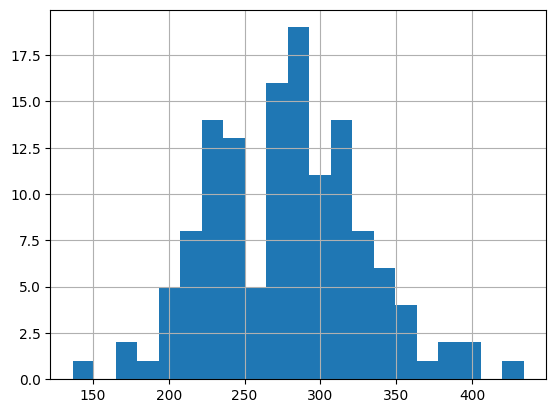

In [4]:
data["oranges"].hist(bins=21)

In [5]:
data.describe()

,tree_number,oranges
count,133.00000,133.000000
mean,1289.00000,277.852803
std,38.53786,50.922243
min,1223.00000,137.023145
25%,1256.00000,237.696112
50%,1289.00000,279.470482
75%,1322.00000,312.079787
max,1355.00000,434.025714


In [6]:
population_mean = 271.93

In [7]:
t, p = stats.ttest_1samp(a = data["oranges"], popmean = population_mean)
print(f"t_value = {t}")
print(f"p_value = {p}")

t_value = 1.3413606837344207
p_value = 0.18210666026278088


The difference between the sample mean of oranges and the population mean is not statistically significant.

In other words, we cannot state with statistical confidence that the mean of oranges is different from the population_mean.

# 2. IELTS

In [8]:
ielts_iran = pd.read_csv("/content/drive/MyDrive/Statistics/ielts_IR.csv")
ielts_iraq = pd.read_csv("/content/drive/MyDrive/Statistics/ielts_IRQ.csv")

In [9]:
ielts_iran.head(10)

,student_code,ielts
0,278917,6.330613
1,278918,7.275424
2,278919,7.012370
3,278920,5.564860
4,278921,5.607750
5,278922,7.286776
6,278923,8.539162
7,278924,4.972318
8,278925,6.304592
9,278926,5.828709


In [10]:
ielts_iraq.head(10)

,student_code,ielts
0,3141112,8.725932
1,3141113,8.144126
2,3141114,6.419268
3,3141115,5.458811
4,3141116,9.303161
5,3141117,8.075198
6,3141118,7.168100
7,3141119,7.049231
8,3141120,7.017530
9,3141121,6.611315


<Axes: >

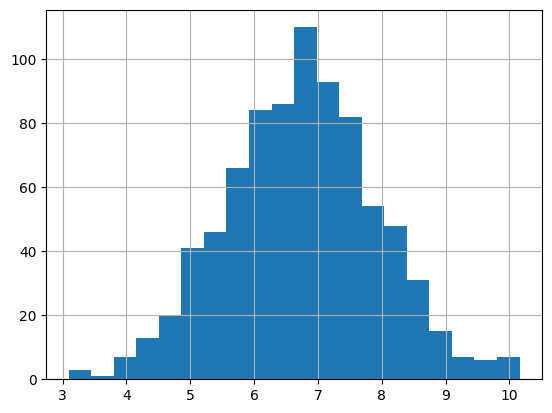

In [11]:
ielts_iran["ielts"].hist(bins=20)

<Axes: >

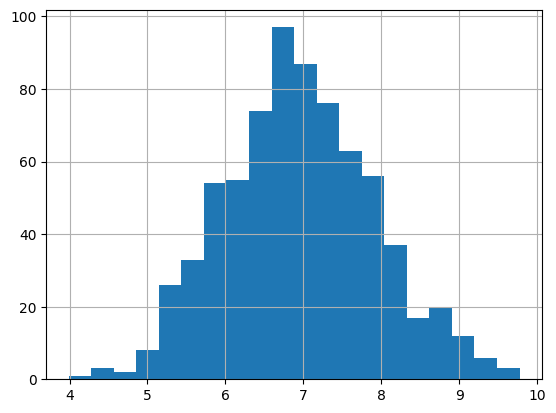

In [12]:
ielts_iraq["ielts"].hist(bins=20)

In [13]:
ielts_iran.describe()

,student_code,ielts
count,820.000000,820.000000
mean,279326.500000,6.754804
std,236.857904,1.178691
min,278917.000000,3.094945
25%,279121.750000,5.971638
50%,279326.500000,6.775687
75%,279531.250000,7.532372
max,279736.000000,10.159504


In [14]:
ielts_iraq.describe()

,student_code,ielts
count,7.300000e+02,730.000000
mean,3.141476e+06,6.956215
std,2.108771e+02,0.964884
min,3.141112e+06,3.988457
25%,3.141294e+06,6.302632
50%,3.141476e+06,6.912297
75%,3.141659e+06,7.617062
max,3.141841e+06,9.772641


In [15]:
from scipy.stats import shapiro

In [16]:
print(f"Shapiro of Iran: {shapiro(ielts_iran['ielts'])}")
print(f"Shapiro of Iraq: {shapiro(ielts_iraq['ielts'])}")

Shapiro of Iran: ShapiroResult(statistic=np.float64(0.9986569017835083), pvalue=np.float64(0.8026722501359616))
Shapiro of Iraq: ShapiroResult(statistic=np.float64(0.9969682540621324), pvalue=np.float64(0.18815401931732378))


In [17]:
t, p = stats.ttest_ind(a = ielts_iran["ielts"], b = ielts_iraq["ielts"])
print(f"t_value = {t}")
print(f"p_value = {p}")

t_value = -3.6538217675570297
p_value = 0.00026698442613130104


In this independent t-test, the t-value is –3.65; the negative sign indicates that the mean IELTS score of Iran is lower than that of Iraq. The p-value is 0.00026, which is far below 0.05. Therefore, the null hypothesis is rejected, and we conclude that the average IELTS scores of Iran and Iraq differ significantly, and this difference is not due to chance.

In [19]:
weight = pd.read_csv("/content/drive/MyDrive/Statistics/weights_change.csv")
weight.head(5)

,weight_before,weight_after
0,65.126024,69.579014
1,67.081931,70.142003
2,72.380314,67.482958
3,63.592077,64.890133
4,57.333414,70.430886


array([[<Axes: title={'center': 'weight_before'}>,
        <Axes: title={'center': 'weight_after'}>]], dtype=object)

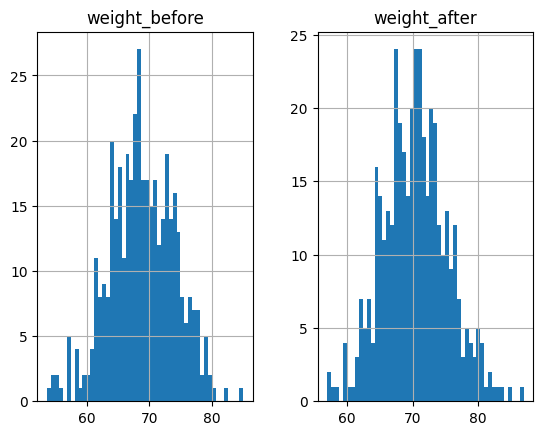

In [20]:
weight.hist(bins = 50)

In [21]:
weight.describe()

,weight_before,weight_after
count,410.000000,410.000000
mean,68.863354,70.425341
std,5.243526,4.975498
min,53.647173,56.991774
25%,65.136296,67.184292
50%,68.669384,70.455450
75%,72.729821,73.506856
max,85.056591,86.939716


In [23]:
t, p = stats.ttest_ind(a = weight['weight_before'] , b = weight['weight_after'] )
print(f"t_value = {t}")
print(f"p_value = {p}")

t_value = -4.375479360871159
p_value = 1.368403297535453e-05


In [24]:
t, p = stats.ttest_rel(a = weight['weight_before'] , b = weight['weight_after'] )
print(f"t_value = {t}")
print(f"p_value = {p}")

t_value = -4.4624675042842386
p_value = 1.0488324309628723e-05


Since the data represent before/after measurements, the only appropriate test is the paired t-test.

The very small p-value indicates that the weight reduction is real and not due to random chance.

The participants’ weights decreased significantly after the intervention period.